# Football Dataset Visualizations - 50km Threshold

Creates 4 professional visualizations for presentation.

**Input:** premier_league_lner_50km_threshold.csv  
**Output:** 4 PNG charts (300 DPI) ready for PowerPoint

**Charts:**
1. Station distribution (4 stations)
2. Capacity vs attendance
3. Top 10 stadiums
4. Summary statistics

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

Libraries imported successfully


In [10]:
# Load dataset
DATASET_FILE = 'Clean dataset.csv'

df = pd.read_csv(DATASET_FILE)
print(f"Dataset loaded: {len(df)} rows × {len(df.columns)} columns")
print(f"Using file: {DATASET_FILE}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset loaded: 361 rows × 7 columns
Using file: Clean dataset.csv

Columns: ['stadium_name', 'stadium_city', 'stadium_lat', 'stadium_lon', 'stadium_capacity', 'nearest_lner_station', 'estimated_attendance']

First 3 rows:


,stadium_name,stadium_city,stadium_lat,stadium_lon,stadium_capacity,nearest_lner_station,estimated_attendance
0,Craven Cottage,London,51.4749,-0.2217,29600,Kings Cross London,26640
1,St James' Park,Newcastle,54.9756,-1.6217,52305,Newcastle Central,47074
2,Tottenham Hotspur Stadium,London,51.6043,-0.0664,62850,Kings Cross London,56565


## Visualization 1: LNER Station Distribution (MOST IMPORTANT)

Saved: 1_station_distribution.png


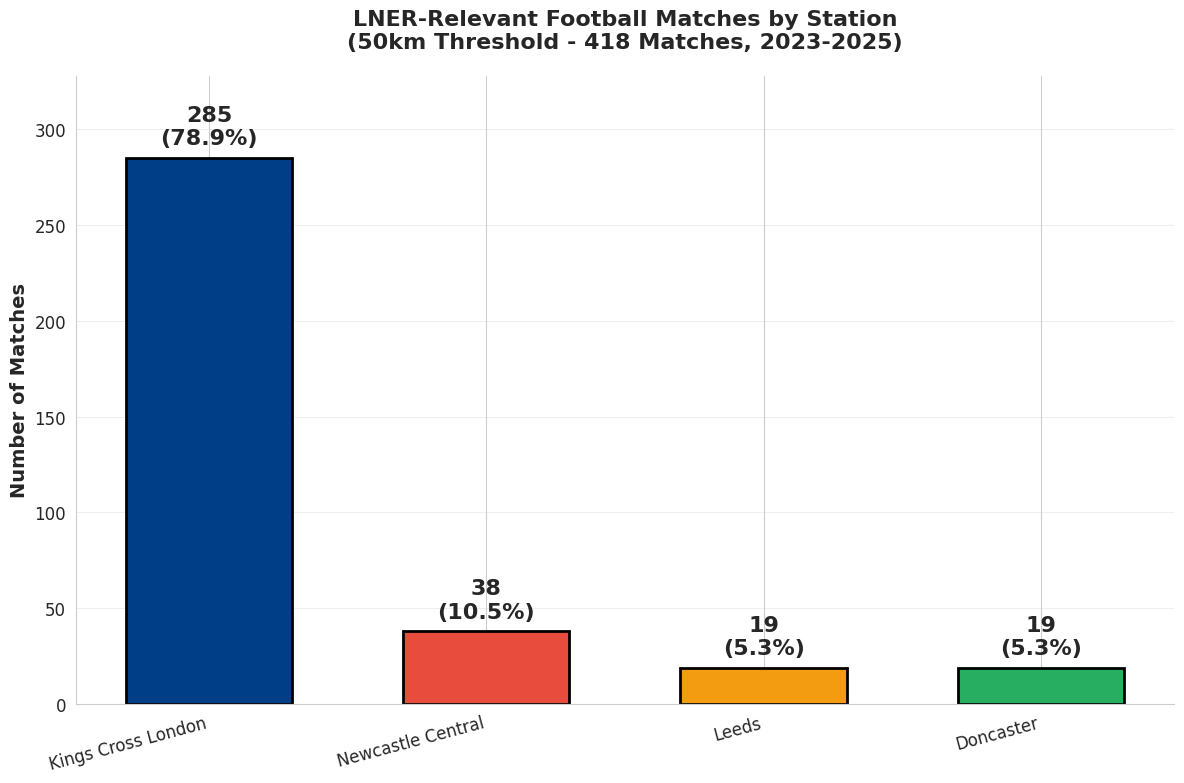

In [11]:
# Count matches by station
station_counts = df['nearest_lner_station'].value_counts()
total = len(df)
percentages = (station_counts / total * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 8))

# 4 colors for 4 stations
color_palette = {
    'Kings Cross London': '#003f87',  # LNER navy blue
    'Newcastle Central': '#e74c3c',   # Red
    'Doncaster': '#27ae60',           # Green
    'Leeds': '#f39c12'                # Orange
}
colors = [color_palette.get(station, '#95a5a6') for station in station_counts.index]
bars = ax.bar(station_counts.index, station_counts.values,
               color=colors, edgecolor='black', linewidth=2, width=0.6)

ax.set_ylabel('Number of Matches', fontsize=14, fontweight='bold')
ax.set_title('LNER-Relevant Football Matches by Station\n(50km Threshold - 418 Matches, 2023-2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, max(station_counts.values) * 1.15)

# Add value labels with percentages
for i, (bar, count, pct) in enumerate(zip(bars, station_counts.values, percentages.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(count)}\n({pct}%)',
            ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels if needed
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('1_station_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: 1_station_distribution.png")
plt.show()

## Visualization 2: Stadium Capacity vs Estimated Attendance

Saved: 2_capacity_vs_attendance.png


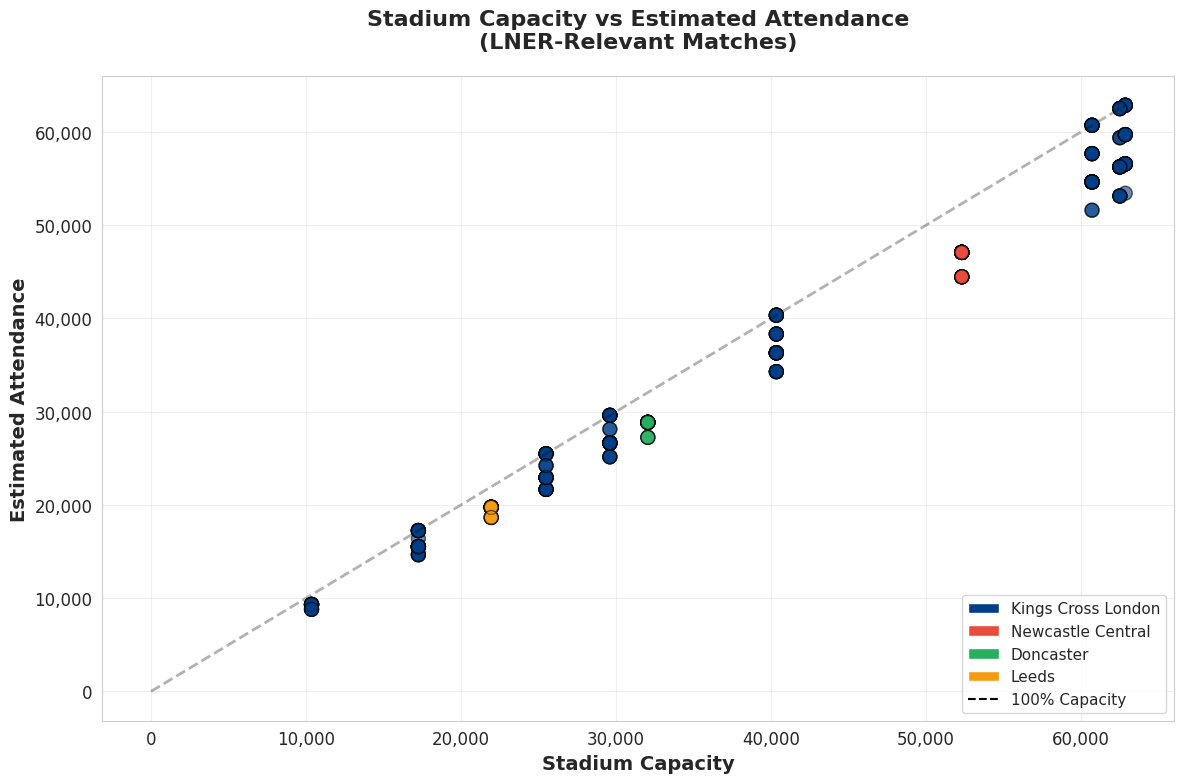

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

# Color by station (4 stations)
color_palette = {
    'Kings Cross London': '#003f87',
    'Newcastle Central': '#e74c3c',
    'Doncaster': '#27ae60',
    'Leeds': '#f39c12'
}
colors = df['nearest_lner_station'].map(color_palette)

scatter = ax.scatter(df['stadium_capacity'], df['estimated_attendance'],
                    c=colors, s=100, alpha=0.6, edgecolor='black', linewidth=1)

# 100% capacity line
max_val = df['stadium_capacity'].max()
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='100% Capacity')

ax.set_xlabel('Stadium Capacity', fontsize=14, fontweight='bold')
ax.set_ylabel('Estimated Attendance', fontsize=14, fontweight='bold')
ax.set_title('Stadium Capacity vs Estimated Attendance\n(LNER-Relevant Matches)',
             fontsize=16, fontweight='bold', pad=20)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Legend (4 stations)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#003f87', label='Kings Cross London'),
    Patch(facecolor='#e74c3c', label='Newcastle Central'),
    Patch(facecolor='#27ae60', label='Doncaster'),
    Patch(facecolor='#f39c12', label='Leeds'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='100% Capacity')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2_capacity_vs_attendance.png', dpi=300, bbox_inches='tight')
print("Saved: 2_capacity_vs_attendance.png")
plt.show()

## Visualization 3: Top 10 Stadiums by Matches

Saved: 3_matches_by_stadium.png


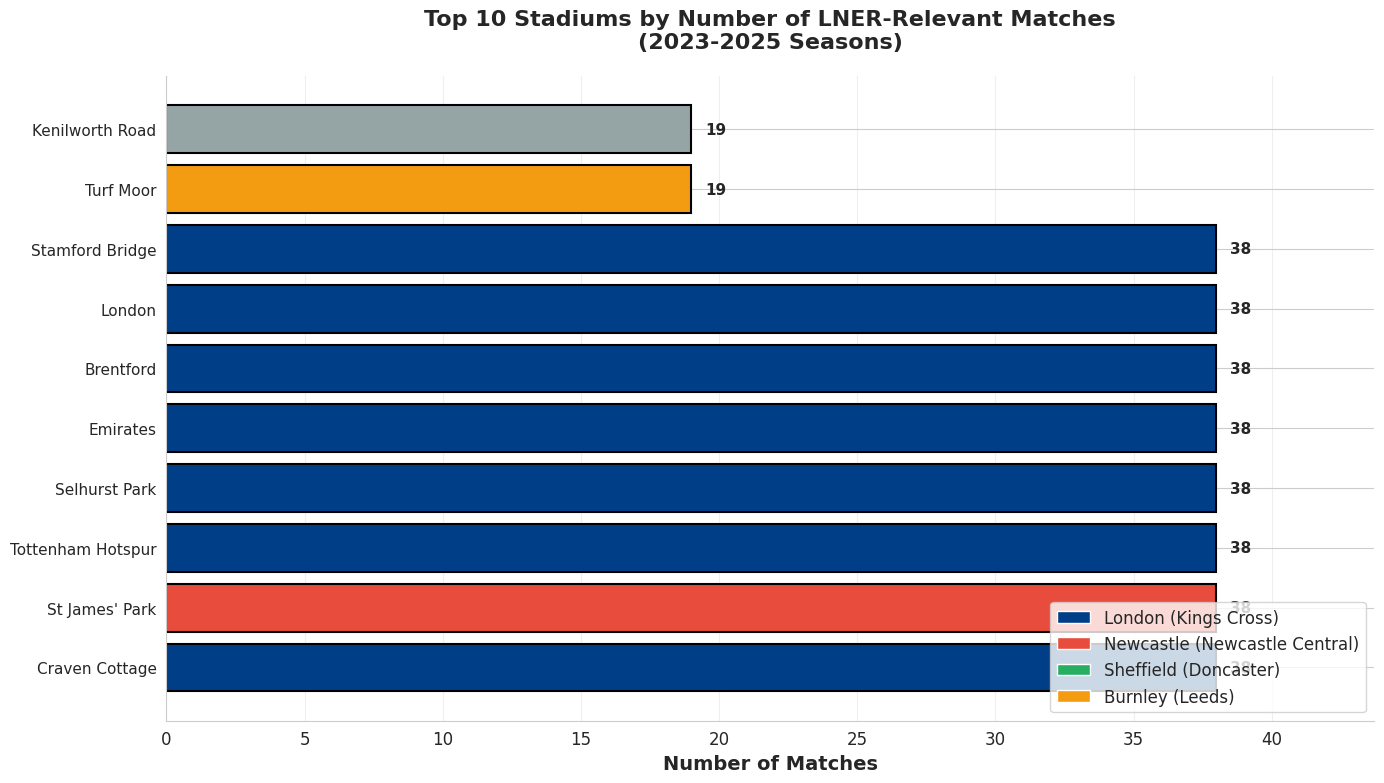

In [13]:
stadium_counts = df['stadium_name'].value_counts().head(10)
cities = [df[df['stadium_name'] == stadium]['stadium_city'].iloc[0]
          for stadium in stadium_counts.index]

# Color by city (4 stations)
color_map = {
    'London': '#003f87',      # Kings Cross
    'Newcastle': '#e74c3c',   # Newcastle Central
    'Sheffield': '#27ae60',   # Doncaster
    'Burnley': '#f39c12'      # Leeds
}
colors = [color_map.get(city, '#95a5a6') for city in cities]

fig, ax = plt.subplots(figsize=(14, 8))

y_pos = np.arange(len(stadium_counts))
bars = ax.barh(y_pos, stadium_counts.values, color=colors,
               edgecolor='black', linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([name.replace(' Stadium', '').replace('Gtech Community', 'Brentford')
                    for name in stadium_counts.index], fontsize=11)
ax.set_xlabel('Number of Matches', fontsize=14, fontweight='bold')
ax.set_title('Top 10 Stadiums by Number of LNER-Relevant Matches\n(2023-2025 Seasons)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0, max(stadium_counts.values) * 1.15)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, stadium_counts.values)):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{int(count)}', ha='left', va='center', fontsize=11, fontweight='bold')

# Legend (4 stations)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#003f87', label='London (Kings Cross)'),
    Patch(facecolor='#e74c3c', label='Newcastle (Newcastle Central)'),
    Patch(facecolor='#27ae60', label='Sheffield (Doncaster)'),
    Patch(facecolor='#f39c12', label='Burnley (Leeds)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('3_matches_by_stadium.png', dpi=300, bbox_inches='tight')
print("Saved: 3_matches_by_stadium.png")
plt.show()

## Visualization 4: Summary Statistics Table

Saved: 4_summary_statistics.png


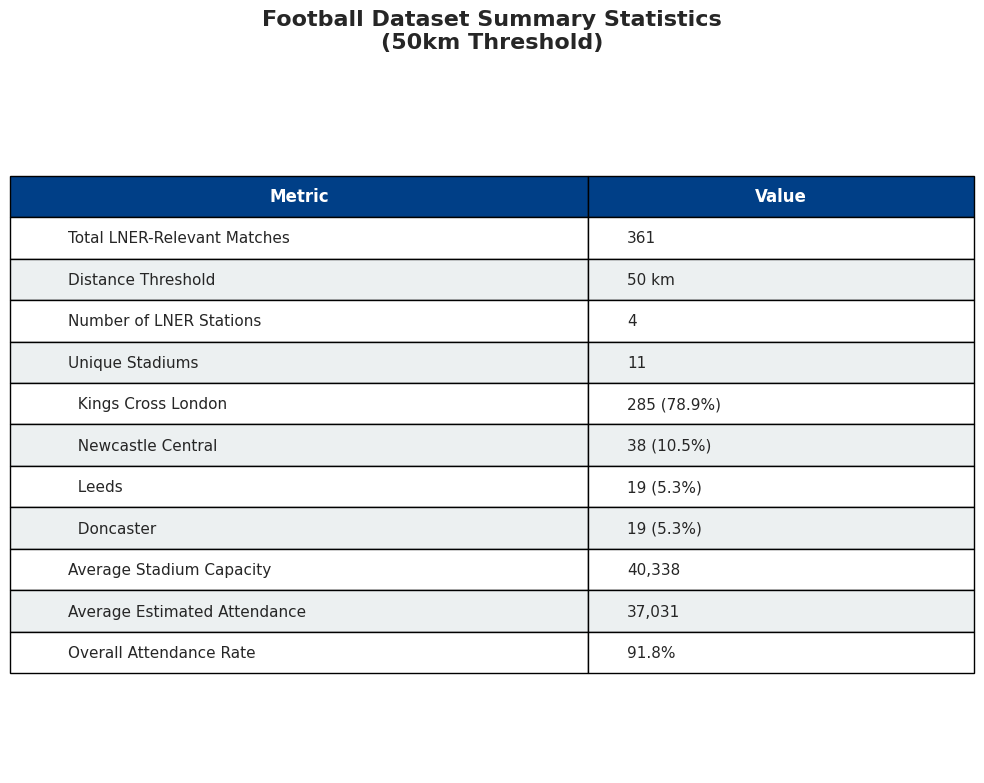

In [14]:
total_matches = len(df)
unique_stadiums = df['stadium_name'].nunique()
avg_capacity = df['stadium_capacity'].mean()
avg_attendance = df['estimated_attendance'].mean()
attendance_rate = (df['estimated_attendance'].sum() / df['stadium_capacity'].sum() * 100)

# Get station breakdown
station_counts = df['nearest_lner_station'].value_counts()
num_stations = len(station_counts)

summary_data = [
    ['Total LNER-Relevant Matches', f'{total_matches}'],
    ['Distance Threshold', '50 km'],
    ['Number of LNER Stations', f'{num_stations}'],
    ['Unique Stadiums', f'{unique_stadiums}'],
]

# Add each station
for station, count in station_counts.items():
    pct = count / total_matches * 100
    summary_data.append([f'  {station}', f'{count} ({pct:.1f}%)'])

summary_data.extend([
    ['Average Stadium Capacity', f'{avg_capacity:,.0f}'],
    ['Average Estimated Attendance', f'{avg_attendance:,.0f}'],
    ['Overall Attendance Rate', f'{attendance_rate:.1f}%'],
])

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_data,
                colLabels=['Metric', 'Value'],
                cellLoc='left',
                loc='center',
                colWidths=[0.6, 0.4])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Style header
for i in range(2):
    table[(0, i)].set_facecolor('#003f87')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=12)

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    if i % 2 == 0:
        for j in range(2):
            table[(i, j)].set_facecolor('#ecf0f1')

plt.title('Football Dataset Summary Statistics\n(50km Threshold)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('4_summary_statistics.png', dpi=300, bbox_inches='tight')
print("Saved: 4_summary_statistics.png")
plt.show()

## Summary

In [15]:
print("\n" + "=" * 80)
print("SUCCESS! All visualizations created")
print("=" * 80)

print("\nFiles created:")
print("  1. 1_station_distribution.png       - MOST IMPORTANT (4 stations at 50km)")
print("  2. 2_capacity_vs_attendance.png     - Shows attendance patterns")
print("  3. 3_matches_by_stadium.png         - Top 10 stadiums")
print("  4. 4_summary_statistics.png         - Key numbers table")

print("\n📊 KEY INSIGHTS FOR PRESENTATION:")
print(f"  • {len(df)} LNER-relevant matches (50km threshold)")
stations = df['nearest_lner_station'].value_counts()
for station, count in stations.items():
    pct = count / len(df) * 100
    print(f"  • {count} at {station} ({pct:.1f}%)")
print(f"  • Average attendance: {df['estimated_attendance'].mean():,.0f}")

print("\n💡 RECOMMENDED FOR PRESENTATION:")
print("  Use #1 (station distribution) - Shows 4-station coverage")
print("  Use #2 or #3 as supporting visual")
print("  Use #4 for detailed statistics slide")

print("\n" + "=" * 80)


SUCCESS! All visualizations created

Files created:
  1. 1_station_distribution.png       - MOST IMPORTANT (4 stations at 50km)
  2. 2_capacity_vs_attendance.png     - Shows attendance patterns
  3. 3_matches_by_stadium.png         - Top 10 stadiums
  4. 4_summary_statistics.png         - Key numbers table

📊 KEY INSIGHTS FOR PRESENTATION:
  • 361 LNER-relevant matches (50km threshold)
  • 285 at Kings Cross London (78.9%)
  • 38 at Newcastle Central (10.5%)
  • 19 at Leeds (5.3%)
  • 19 at Doncaster (5.3%)
  • Average attendance: 37,031

💡 RECOMMENDED FOR PRESENTATION:
  Use #1 (station distribution) - Shows 4-station coverage
  Use #2 or #3 as supporting visual
  Use #4 for detailed statistics slide



## Download All Images (Google Colab Only)

In [16]:
from google.colab import files

files.download('1_station_distribution.png')
files.download('2_capacity_vs_attendance.png')
files.download('3_matches_by_stadium.png')
files.download('4_summary_statistics.png')

print("All visualizations downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All visualizations downloaded!
